In [31]:
import os

In [32]:
import warnings
import os
warnings.filterwarnings('ignore')
# Get all the paths
dataset_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection - My\Dataset'
dataset_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection - My\Dataset'

if not os.path.isdir(dataset_dir):
    alternative_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection - My\Dataset'

    if os.path.isdir(alternative_dir):
        dataset_dir = alternative_dir
    else:
        raise FileNotFoundError(f"Dataset directory not found: {dataset_dir}")

data_dir_list = os.listdir(dataset_dir)
print(data_dir_list)
path, dirs, files = next(os.walk(dataset_dir))
file_count = len(files)
#print(file_count)

['Benign cases', 'Malignant cases', 'Normal cases']


In [34]:
# Make new base directory
original_dataset_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection - My\Dataset'
base_dir = r'C:\Users\Devar\Desktop\Lung Cancer Detection - My\Backend\Split_data_vgg16'
os.makedirs(base_dir, exist_ok=True)

In [35]:
import os
import random
from shutil import copyfile

In [36]:
def split_data(SOURCE, TRAINING, VALIDATION, TESTING, SPLIT_SIZE):
    files = []
    for filename in os.listdir(SOURCE):
        file = SOURCE + filename
        if os.path.getsize(file) > 0:
            files.append(filename)
        else:
            print(filename + " is zero length, so ignoring.")

    training_length = int(len(files) * SPLIT_SIZE)
    valid_length = int(len(files) - training_length)
    shuffled_set = random.sample(files, len(files))
    training_set = shuffled_set[0:training_length]
    valid_set = shuffled_set[training_length:]

    for filename in training_set:
        this_file = SOURCE + filename
        destination = TRAINING + filename
        copyfile(this_file, destination)

    for filename in valid_set:
        this_file = SOURCE + filename
        destination = VALIDATION + filename
        copyfile(this_file, destination)

In [38]:
import os

# ------------------------------------------------------------------
# Paths (no Dataset1 anywhere)
# ------------------------------------------------------------------
backend_dir  = os.getcwd()                              # ...\Lung Cancer Detection - My\Backend
project_root = os.path.dirname(backend_dir)             # ...\Lung Cancer Detection - My

# Source images
data_dir = os.path.join(project_root, 'Dataset')

# Split output, inside Backend
base_dir       = os.path.join(backend_dir, 'Split_data_vgg16')
train_dir      = os.path.join(base_dir, 'Train')
validation_dir = os.path.join(base_dir, 'Validation')
testing_dir    = os.path.join(base_dir, 'Testing')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(validation_dir, exist_ok=True)
os.makedirs(testing_dir, exist_ok=True)

# ------------------------------------------------------------------
# Per-class folders
# ------------------------------------------------------------------
train_cloud_dir  = os.path.join(train_dir, 'Benign cases')
train_foggy_dir  = os.path.join(train_dir, 'Malignant cases')
train_normal_dir = os.path.join(train_dir, 'Normal cases')

validation_cloud_dir  = os.path.join(validation_dir, 'Benign cases')
validation_foggy_dir  = os.path.join(validation_dir, 'Malignant cases')
validation_normal_dir = os.path.join(validation_dir, 'Normal cases')

Testing_cloud_dir  = os.path.join(testing_dir, 'Benign cases')
Testing_foggy_dir  = os.path.join(testing_dir, 'Malignant cases')
Testing_normal_dir = os.path.join(testing_dir, 'Normal cases')

for d in (train_cloud_dir, train_foggy_dir, train_normal_dir,
          validation_cloud_dir, validation_foggy_dir, validation_normal_dir,
          Testing_cloud_dir, Testing_foggy_dir, Testing_normal_dir):
    os.makedirs(d, exist_ok=True)

# ------------------------------------------------------------------
# Source folders
# ------------------------------------------------------------------
BENGIN_SOURCE_DIR    = os.path.join(data_dir, 'Benign cases')
MALIGNANT_SOURCE_DIR = os.path.join(data_dir, 'Malignant cases')
NORMAL_SOURCE_DIR    = os.path.join(data_dir, 'Normal cases')

for d in (BENGIN_SOURCE_DIR, MALIGNANT_SOURCE_DIR, NORMAL_SOURCE_DIR):
    if not os.path.isdir(d):
        raise FileNotFoundError(f"Source folder missing: {d}")

# ------------------------------------------------------------------
# Target aliases used by split_data
# ------------------------------------------------------------------
TRAINING_BENGIN_DIR = train_cloud_dir
VALID_BENGIN_DIR    = validation_cloud_dir
TESTING_BENGIN_DIR  = Testing_cloud_dir

TRAINING_MALIGNANT_DIR = train_foggy_dir
VALID_MALIGNANT_DIR    = validation_foggy_dir
TESTING_MALIGNANT_DIR  = Testing_foggy_dir

TRAINING_NORMAL_DIR = train_normal_dir
VALID_NORMAL_DIR    = validation_normal_dir
TESTING_NORMAL_DIR  = Testing_normal_dir

print("Source :", data_dir)
print("Output :", base_dir)

Source : c:\Users\Devar\Desktop\Lung Cancer Detection - My\Dataset
Output : c:\Users\Devar\Desktop\Lung Cancer Detection - My\Backend\Split_data_vgg16


In [39]:
import os
import random
import shutil
from shutil import copyfile

# ------------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------------
SEED = 42
random.seed(SEED)                 # reproducible split for the report

TRAIN_RATIO = 0.70                # 70%
TEST_RATIO  = 0.15                # 15%
VALID_RATIO = 0.15                # 15% (takes the rounding remainder)

assert abs(TRAIN_RATIO + TEST_RATIO + VALID_RATIO - 1.0) < 1e-9, \
    "Ratios must sum to 1.0"

CLEAR_EXISTING = True             # empty the nine class folders before copying

# ------------------------------------------------------------------
# 2. Class map: source -> (train, validation, testing)
# ------------------------------------------------------------------
CLASS_MAP = {
    'Benign cases': (
        BENGIN_SOURCE_DIR,    TRAINING_BENGIN_DIR,    VALID_BENGIN_DIR,    TESTING_BENGIN_DIR),
    'Malignant cases': (
        MALIGNANT_SOURCE_DIR, TRAINING_MALIGNANT_DIR, VALID_MALIGNANT_DIR, TESTING_MALIGNANT_DIR),
    'Normal cases': (
        NORMAL_SOURCE_DIR,    TRAINING_NORMAL_DIR,    VALID_NORMAL_DIR,    TESTING_NORMAL_DIR),
}

# ------------------------------------------------------------------
# 3. Clear previous contents (folders themselves are kept)
# ------------------------------------------------------------------
if CLEAR_EXISTING:
    for _, tr, va, te in CLASS_MAP.values():
        for folder in (tr, va, te):
            for name in os.listdir(folder):
                path = os.path.join(folder, name)
                shutil.rmtree(path) if os.path.isdir(path) else os.remove(path)

# ------------------------------------------------------------------
# 4. Split function
# ------------------------------------------------------------------
def split_data(source, training, validation, testing,
               train_ratio=TRAIN_RATIO, test_ratio=TEST_RATIO):
    files = []
    for filename in os.listdir(source):
        file_path = os.path.join(source, filename)
        if os.path.isfile(file_path):
            if os.path.getsize(file_path) > 0:
                files.append(filename)
            else:
                print(filename + " is zero length, so ignoring.")

    n = len(files)
    shuffled = random.sample(files, n)

    train_end = int(n * train_ratio)
    test_end  = train_end + int(n * test_ratio)

    subsets = {
        training:   shuffled[:train_end],
        testing:    shuffled[train_end:test_end],
        validation: shuffled[test_end:],       # remainder, so no image is lost
    }

    for destination, subset in subsets.items():
        for filename in subset:
            copyfile(os.path.join(source, filename),
                     os.path.join(destination, filename))

    return len(subsets[training]), len(subsets[validation]), len(subsets[testing])

# ------------------------------------------------------------------
# 5. Run the split
# ------------------------------------------------------------------
print(f"Ratio  Train {TRAIN_RATIO:.0%} : Validation {VALID_RATIO:.0%} : Testing {TEST_RATIO:.0%}\n")
print(f"{'Class':<18}{'Total':>8}{'Train':>8}{'Valid':>8}{'Test':>8}")

totals = [0, 0, 0]
for cls, (src, tr_dir, va_dir, te_dir) in CLASS_MAP.items():
    tr, va, te = split_data(src, tr_dir, va_dir, te_dir)
    totals = [totals[0] + tr, totals[1] + va, totals[2] + te]
    print(f"{cls:<18}{tr+va+te:>8}{tr:>8}{va:>8}{te:>8}")

grand = sum(totals)
print(f"{'TOTAL':<18}{grand:>8}{totals[0]:>8}{totals[1]:>8}{totals[2]:>8}")
print(f"{'Actual %':<18}{100.0:>8.1f}"
      f"{totals[0]/grand*100:>8.1f}{totals[1]/grand*100:>8.1f}{totals[2]/grand*100:>8.1f}")

print("\nSource :", data_dir)
print("Output :", base_dir)

Ratio  Train 70% : Validation 15% : Testing 15%

Class                Total   Train   Valid    Test
Benign cases          1200     840     180     180
Malignant cases       1201     840     181     180
Normal cases          1208     845     182     181
TOTAL                 3609    2525     543     541
Actual %             100.0    70.0    15.0    15.0

Source : c:\Users\Devar\Desktop\Lung Cancer Detection - My\Dataset
Output : c:\Users\Devar\Desktop\Lung Cancer Detection - My\Backend\Split_data_vgg16


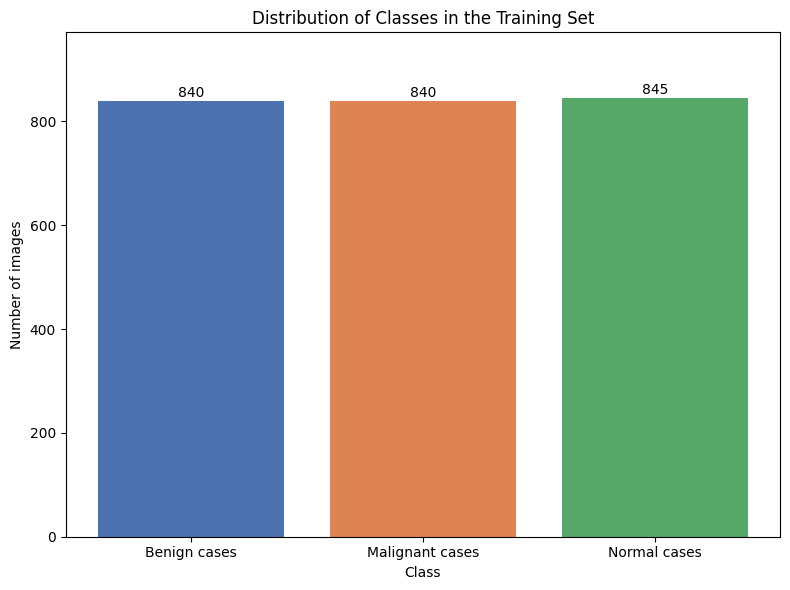

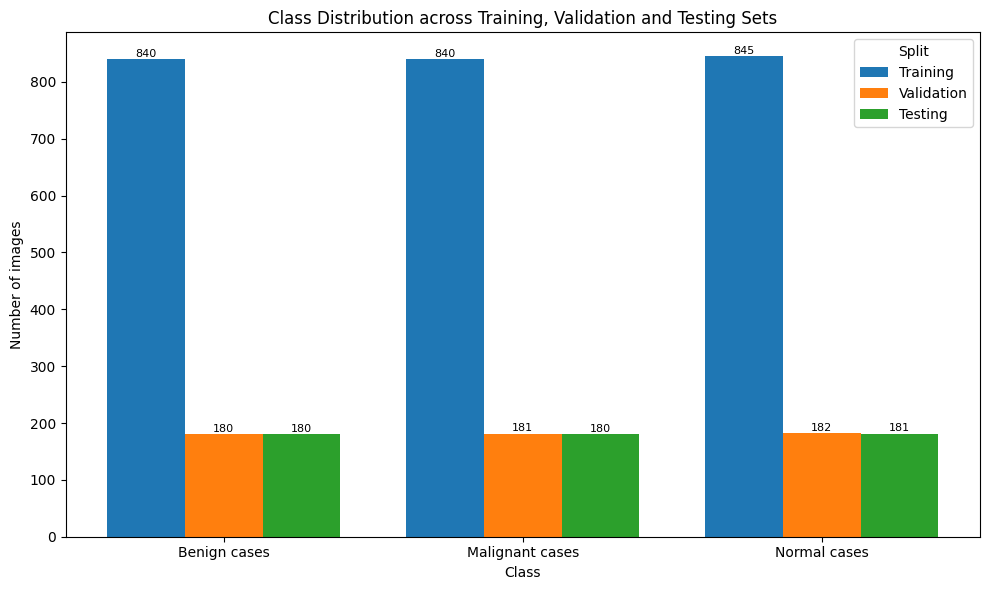

Class                Train   Valid    Test   Total
Benign cases           840     180     180    1200
Malignant cases        840     181     180    1201
Normal cases           845     182     181    1208
TOTAL                 2525     543     541    3609
Share %               70.0    15.0    15.0   100.0


In [40]:
import os
import numpy as np
import matplotlib.pyplot as plt

image_folder = ['Benign cases', 'Malignant cases', 'Normal cases']

SPLIT_DIRS = {
    'Training':   train_dir,
    'Validation': validation_dir,
    'Testing':    testing_dir,
}

IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

# ------------------------------------------------------------------
# 1. Count images (recount every run so the numbers match the split)
# ------------------------------------------------------------------
def count_images(folder):
    if not os.path.isdir(folder):
        return 0
    return len([
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f)) and f.lower().endswith(IMG_EXT)
    ])

counts = {
    split: [count_images(os.path.join(path, cls)) for cls in image_folder]
    for split, path in SPLIT_DIRS.items()
}

nimgs = dict(zip(image_folder, counts['Training']))   # kept for later cells

# ------------------------------------------------------------------
# 2. Training distribution
# ------------------------------------------------------------------
plt.figure(figsize=(8, 6))
bars = plt.bar(image_folder, counts['Training'],
               color=['#4C72B0', '#DD8452', '#55A868'])

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
             f'{int(bar.get_height())}', ha='center', va='bottom')

plt.title('Distribution of Classes in the Training Set')
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.ylim(0, max(counts['Training']) * 1.15)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 3. Training vs Validation vs Testing
# ------------------------------------------------------------------
x = np.arange(len(image_folder))
width = 0.26

plt.figure(figsize=(10, 6))
for i, (split, values) in enumerate(counts.items()):
    offset = (i - 1) * width
    bars = plt.bar(x + offset, values, width, label=split)
    for bar in bars:
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=8)

plt.title('Class Distribution across Training, Validation and Testing Sets')
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.xticks(x, image_folder)
plt.legend(title='Split')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# 4. Summary table
# ------------------------------------------------------------------
print(f"{'Class':<18}{'Train':>8}{'Valid':>8}{'Test':>8}{'Total':>8}")
for i, cls in enumerate(image_folder):
    tr, va, te = counts['Training'][i], counts['Validation'][i], counts['Testing'][i]
    print(f"{cls:<18}{tr:>8}{va:>8}{te:>8}{tr+va+te:>8}")

tot = [sum(counts[s]) for s in ('Training', 'Validation', 'Testing')]
print(f"{'TOTAL':<18}{tot[0]:>8}{tot[1]:>8}{tot[2]:>8}{sum(tot):>8}")
print(f"{'Share %':<18}"
      f"{tot[0]/sum(tot)*100:>8.1f}{tot[1]/sum(tot)*100:>8.1f}{tot[2]/sum(tot)*100:>8.1f}{100.0:>8.1f}")

In [41]:
import os

image_folder = ['Benign cases', 'Malignant cases', 'Normal cases']
IMG_EXT = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

def count_images(folder):
    if not os.path.isdir(folder):
        return 0
    return len([
        f for f in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, f)) and f.lower().endswith(IMG_EXT)
    ])

for i in image_folder:
    print('Training {} images are: '.format(i) + str(count_images(os.path.join(train_dir, i))))

for i in image_folder:
    print('Validation {} images are: '.format(i) + str(count_images(os.path.join(validation_dir, i))))

for i in image_folder:
    print('Testing {} images are: '.format(i) + str(count_images(os.path.join(testing_dir, i))))

Training Benign cases images are: 840
Training Malignant cases images are: 840
Training Normal cases images are: 845
Validation Benign cases images are: 180
Validation Malignant cases images are: 181
Validation Normal cases images are: 182
Testing Benign cases images are: 180
Testing Malignant cases images are: 180
Testing Normal cases images are: 181


In [42]:
!pip install tensorflow==2.21.0


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
